In [2]:
import pandas as pd         # Data manipulation
import numpy as np          # Numerical operations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns      # Statistical data visualization
from scipy.stats import linregress     # Linear regression analysis
# Suppress warnings for cleaner output
import warnings

In [3]:
df = pd.read_csv('International_Education_Costs.csv')
df


,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92
...,...,...,...,...,...,...,...,...,...,...,...,...
902,France,Strasbourg,University of Strasbourg,Data Analytics,Master,2.0,4000,70.2,1000,99,850,0.92
903,Malaysia,Nilai,USIM,Computer Science,Bachelor,3.0,6800,50.5,400,120,400,4.65
904,Saudi Arabia,Al-Ahsa,King Faisal University,Information Systems,Master,2.0,4200,64.2,600,200,800,3.75
905,USA,Seattle,University of Washington,Software Development,PhD,5.0,50000,77.8,2000,160,1500,1.00


## Data exploration -
#### to identify patterns and structures 

In [5]:
print("Shape of dataset:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nDescriptive Statistics:\n", df.describe())
print("\nColumn names:", df.columns.tolist())

Shape of dataset: (907, 12)

Data Types:
 Country               object
City                  object
University            object
Program               object
Level                 object
Duration_Years       float64
Tuition_USD            int64
Living_Cost_Index    float64
Rent_USD               int64
Visa_Fee_USD           int64
Insurance_USD          int64
Exchange_Rate        float64
dtype: object

Descriptive Statistics:
        Duration_Years   Tuition_USD  Living_Cost_Index     Rent_USD  \
count      907.000000    907.000000         907.000000   907.000000   
mean         2.836825  16705.016538          64.437486   969.206174   
std          0.945449  16582.385275          14.056333   517.154752   
min          1.000000      0.000000          27.800000   150.000000   
25%          2.000000   2850.000000          56.300000   545.000000   
50%          3.000000   7500.000000          67.500000   900.000000   
75%          4.000000  31100.000000          72.200000  1300.000000   
ma

# DATA CLEANING - 
#### droping null values & removing duplicate values 


In [7]:
cost_cols = ['Tuition_USD','Living_Cost_Index','Rent_USD','Visa_Fee_USD','Insurance_USD']
df = df.dropna(subset=cost_cols)
df = df[(df[cost_cols] != 0).all(axis=1)]

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92
...,...,...,...,...,...,...,...,...,...,...,...,...
902,France,Strasbourg,University of Strasbourg,Data Analytics,Master,2.0,4000,70.2,1000,99,850,0.92
903,Malaysia,Nilai,USIM,Computer Science,Bachelor,3.0,6800,50.5,400,120,400,4.65
904,Saudi Arabia,Al-Ahsa,King Faisal University,Information Systems,Master,2.0,4200,64.2,600,200,800,3.75
905,USA,Seattle,University of Washington,Software Development,PhD,5.0,50000,77.8,2000,160,1500,1.00


# Data Grouping- 
#### organizes information for trend analysis 

In [12]:
avg_tuition = df.groupby('Country')['Tuition_USD'].mean().sort_values(ascending=False)
avg_tuition.head()
df_grouped = df.groupby('Country').mean(numeric_only=True)
print(df_grouped)

            Duration_Years   Tuition_USD  Living_Cost_Index     Rent_USD  \
Country                                                                    
Algeria           2.800000   1100.000000          35.680000   202.000000   
Australia         2.965116  34610.465116          68.245349  1361.627907   
Austria           2.666667   1500.000000          71.066667   794.444444   
Bahrain           3.200000   7600.000000          62.860000   630.000000   
Bangladesh        2.800000   2220.000000          38.960000   192.000000   
...                    ...           ...                ...          ...   
USA               3.384615  47742.307692          77.796154  1858.974359   
Ukraine           2.800000   3520.000000          42.760000   340.000000   
Uruguay           2.000000   6750.000000          48.850000   390.000000   
Uzbekistan        2.800000   3620.000000          40.360000   230.000000   
Vietnam           4.000000   3200.000000          43.600000   450.000000   

           

In [11]:
df_grouped = df.groupby('Country').mean(numeric_only=True)
print(df_grouped)

            Duration_Years   Tuition_USD  Living_Cost_Index     Rent_USD  \
Country                                                                    
Algeria           2.800000   1100.000000          35.680000   202.000000   
Australia         2.965116  34610.465116          68.245349  1361.627907   
Austria           2.666667   1500.000000          71.066667   794.444444   
Bahrain           3.200000   7600.000000          62.860000   630.000000   
Bangladesh        2.800000   2220.000000          38.960000   192.000000   
...                    ...           ...                ...          ...   
USA               3.384615  47742.307692          77.796154  1858.974359   
Ukraine           2.800000   3520.000000          42.760000   340.000000   
Uruguay           2.000000   6750.000000          48.850000   390.000000   
Uzbekistan        2.800000   3620.000000          40.360000   230.000000   
Vietnam           4.000000   3200.000000          43.600000   450.000000   

           

# DATA VISUALIZATION 

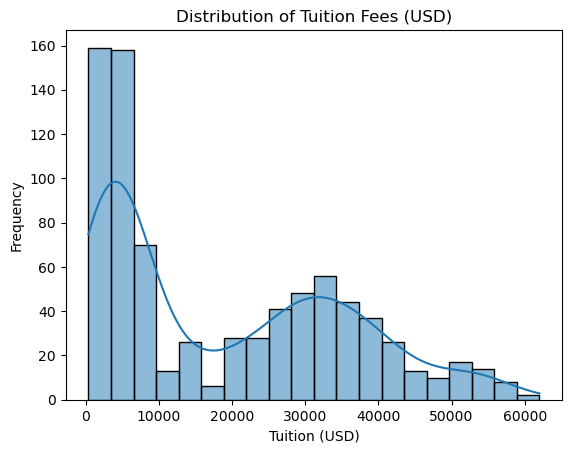

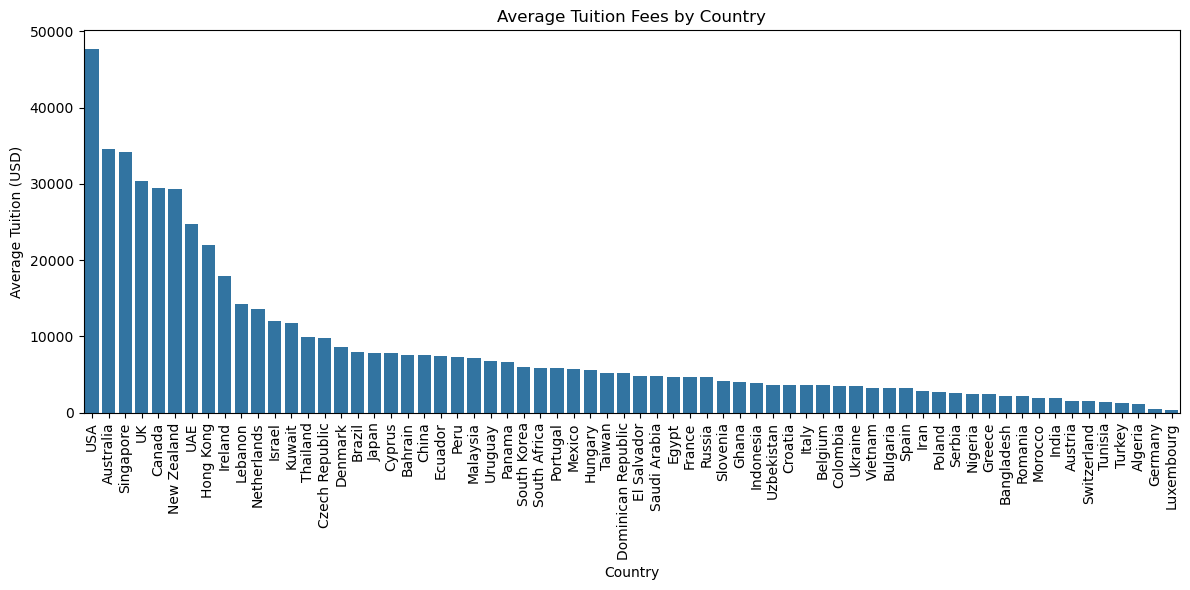

In [20]:
#Distribution of tution fee 
sns.histplot(df['Tuition_USD'], bins=20, kde=True)
plt.title('Distribution of Tuition Fees (USD)')
plt.xlabel('Tuition (USD)')
plt.ylabel('Frequency')
plt.show()

# Grouping: average tuition per country
avg_tuition = df.groupby('Country')['Tuition_USD'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_tuition.index, y=avg_tuition.values)
plt.xticks(rotation=90)
plt.title("Average Tuition Fees by Country")
plt.xlabel("Country")
plt.ylabel("Average Tuition (USD)")
plt.tight_layout()
plt.show()


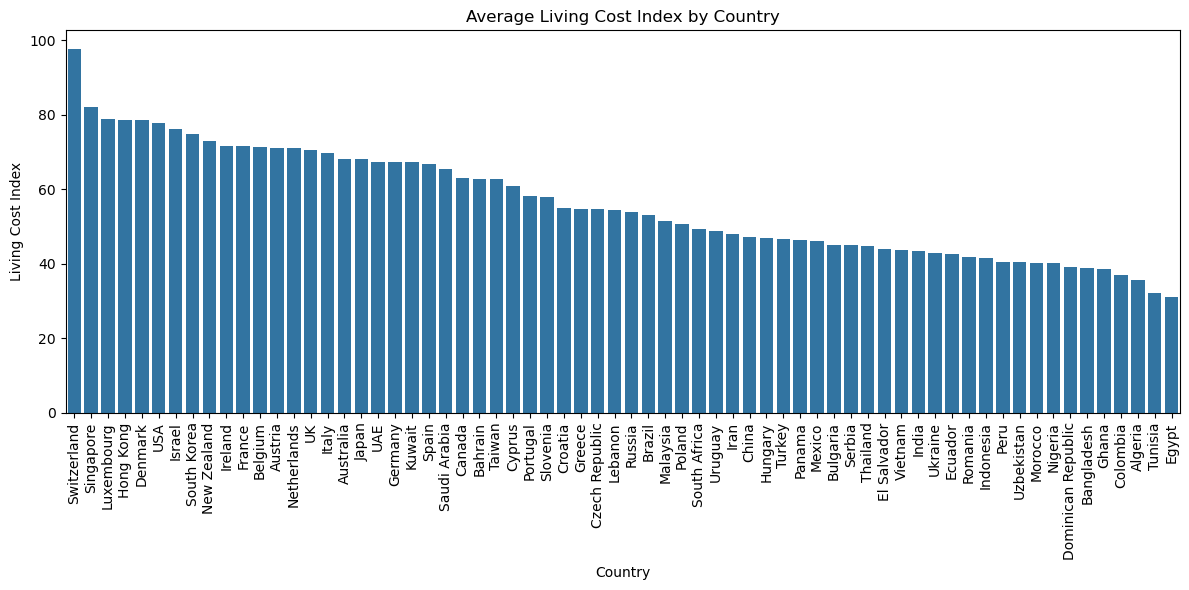

In [17]:

# Sort countries by Living Cost Index
country_living_cost = df.groupby('Country')['Living_Cost_Index'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=country_living_cost.index, y=country_living_cost.values)
plt.xticks(rotation=90)
plt.title('Average Living Cost Index by Country')
plt.xlabel('Country')
plt.ylabel('Living Cost Index')
plt.tight_layout()
plt.show()


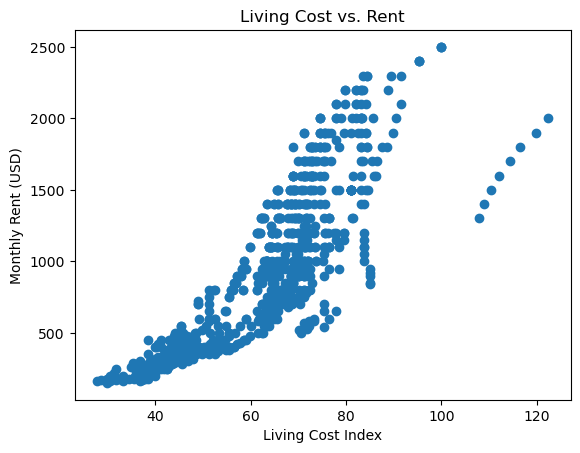

In [23]:
plt.scatter(df['Living_Cost_Index'], df['Rent_USD'])
plt.xlabel('Living Cost Index')
plt.ylabel('Monthly Rent (USD)')
plt.title('Living Cost vs. Rent')
plt.show()


In [25]:
#analyzing top less cost effective countries
def estimate_annual_cost(row):
    tuition = row['Tuition_USD'] / row['Duration_Years']
    living = row['Living_Cost_Index'] / 100 * 12000  # baseline $12k/year
    rent = row['Rent_USD'] * 12
    visa = row['Visa_Fee_USD']
    insurance = row['Insurance_USD']
    return tuition + living + rent + visa + insurance

df['Estimated_Annual_Cost'] = df.apply(estimate_annual_cost, axis=1)
df[['University', 'Estimated_Annual_Cost']].sort_values(by='Estimated_Annual_Cost').head()

,University,Estimated_Annual_Cost
762,University of Carthage,6036.0
679,Mansoura University,6260.0
805,University of Tlemcen,6484.0
685,Aswan University,6506.0
748,University of Monastir,6516.0


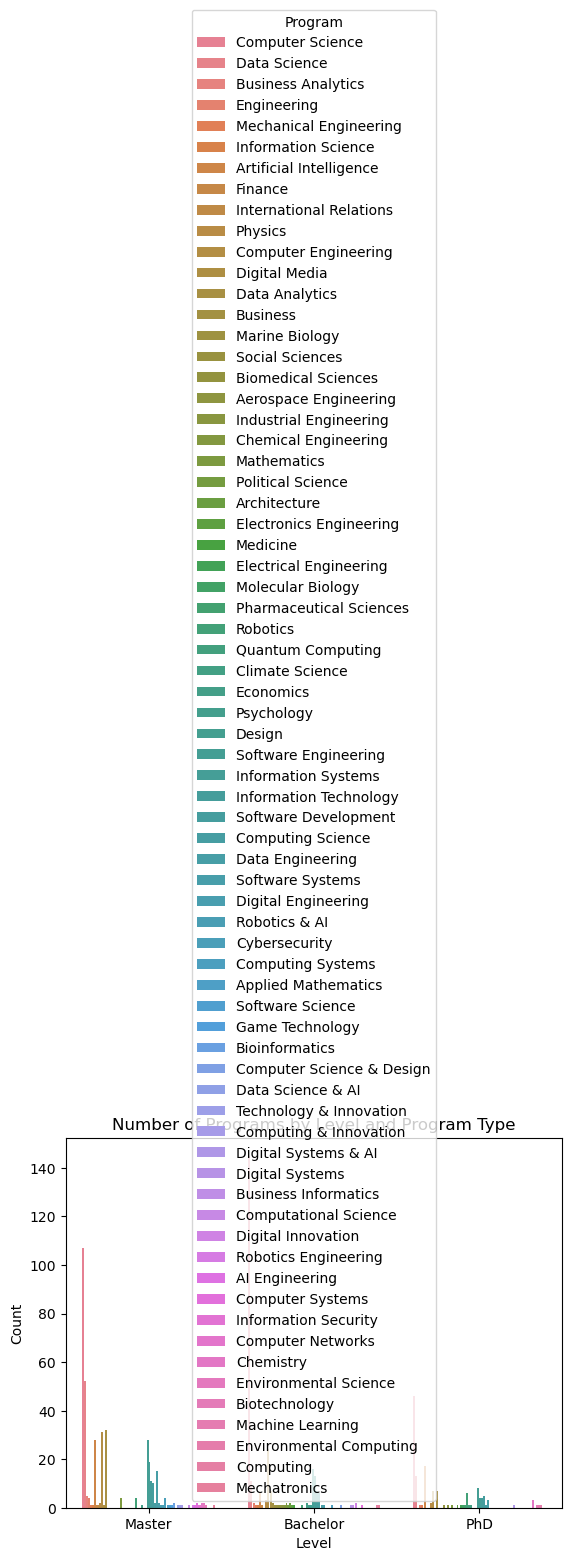

In [26]:
#types of programs 
sns.countplot(x='Level', hue='Program', data=df)
plt.title('Number of Programs by Level and Program Type')
plt.xlabel('Level')
plt.ylabel('Count')
plt.legend(title='Program')
plt.show()

C:\Users\Victus\AppData\Local\Temp\ipykernel_12720\2072826980.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=levels)


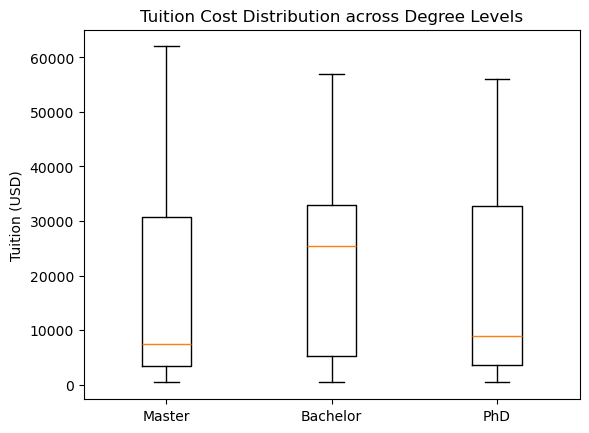

In [28]:
levels = df['Level'].unique()

data = [df[df['Level']==lvl]['Tuition_USD'] for lvl in levels]

plt.boxplot(data, labels=levels)
plt.ylabel('Tuition (USD)')
plt.title('Tuition Cost Distribution across Degree Levels')
plt.show()

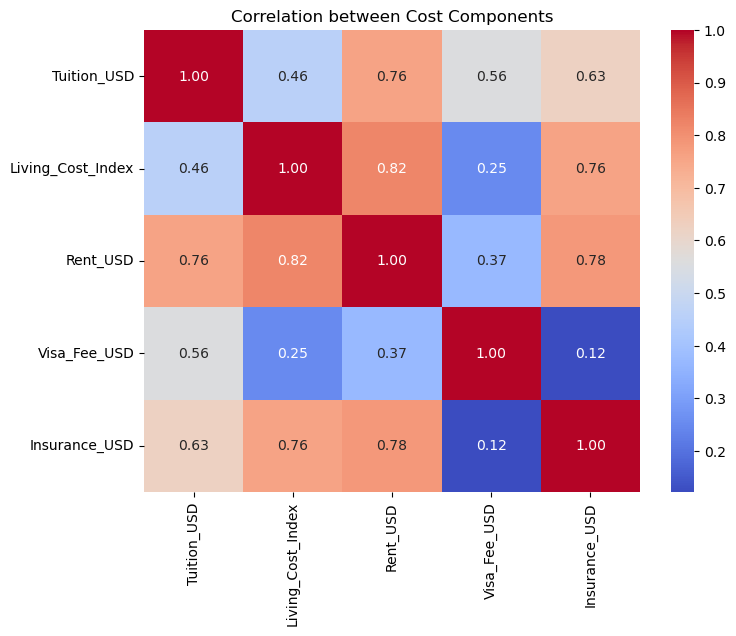

In [30]:
#This code block is generating a correlation heatmap to analyze relationships between various cost-related components
corr_components = df[['Tuition_USD','Living_Cost_Index','Rent_USD','Visa_Fee_USD','Insurance_USD']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_components, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between Cost Components')
plt.show()

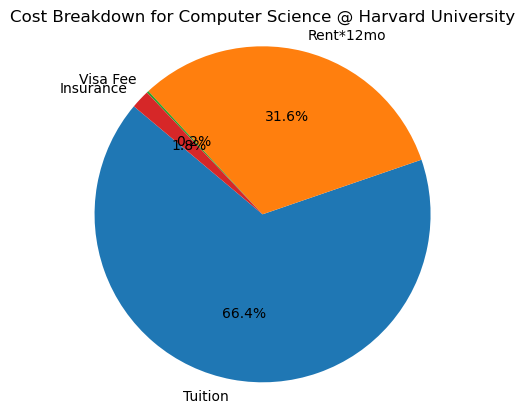

In [32]:
sample = df.loc[0, ['Tuition_USD','Rent_USD','Visa_Fee_USD','Insurance_USD']]
labels = ['Tuition','Rent*12mo','Visa Fee','Insurance']
sizes = [sample['Tuition_USD'], sample['Rent_USD']*12, sample['Visa_Fee_USD'], sample['Insurance_USD']]



plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title(f"Cost Breakdown for {df.loc[0,'Program']} @ {df.loc[0,'University']}")
plt.axis('equal')
plt.show()

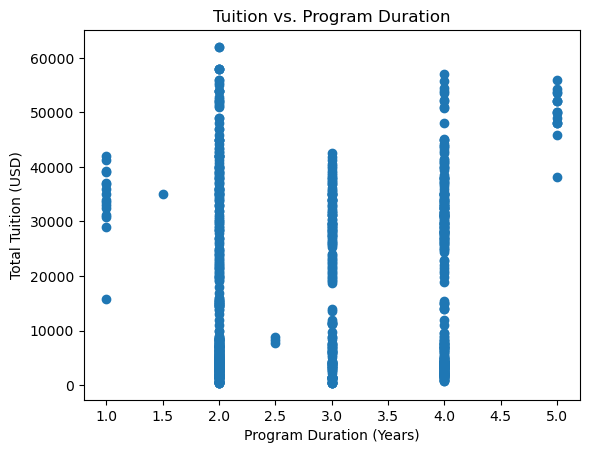

In [34]:
#tution fee with corresponding to program duration
x = df['Duration_Years']
y = df['Tuition_USD']
plt.scatter(x, y)
plt.xlabel('Program Duration (Years)')
plt.ylabel('Total Tuition (USD)')
plt.title('Tuition vs. Program Duration')
plt.show()


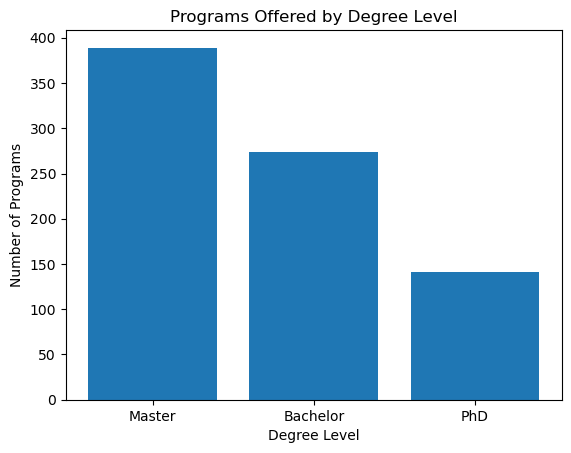

In [35]:
grouped = df['Level'].value_counts()
import matplotlib.pyplot as plt

plt.bar(grouped.index, grouped.values)
plt.xlabel('Degree Level')
plt.ylabel('Number of Programs')
plt.title('Programs Offered by Degree Level')
plt.show()